# Bài tập — Softmax + Grid Search siêu tham số (tập dữ liệu #1: ViHSD)

> **Đề bài (chép nguyên văn ghi chú):**
> - Softmax trên 2 tập dữ liệu cũ
> - Thủ công – Thư viện, So sánh
> - Quy trình 4 bước: khai ở đâu
> - Grid search để tối ưu hóa siêu tham số: lr, epochs, …

Đây là notebook cho **tập dữ liệu cũ #1 — ViHSD** (bình luận mạng xã hội tiếng Việt, 3 lớp: `CLEAN / OFFENSIVE / HATE`, đã dùng ở `b1` và `b7/Softmax_ViHSD.ipynb`). Tập dữ liệu cũ #2 — Hanoi housing — ở notebook `Softmax_GridSearch_Hanoi.ipynb` cùng thư mục.

Khác với `Softmax_ViHSD.ipynb` (đi sâu vào giải tay), bài tập này **trọng tâm là grid search**: quét lưới `(learning rate, epochs)` cho cả bản thuần lẫn bản thư viện, tìm cấu hình tốt nhất trên tập validation, rồi mới đánh giá trên tập test — đúng quy trình chọn siêu tham số không rò rỉ dữ liệu.

## 0. Quy trình 4 bước — khai ở đâu (bảng lộ trình)

| Giai đoạn | Nội dung | Ở mục nào trong notebook này |
|---|---|---|
| **1. Giải tay** | Công thức softmax + entropy chéo + gradient $(P-Y)$; giải chi tiết với bảng kí hiệu + số cụ thể đã có ở `Softmax_ViHSD.ipynb` §3 | §2 (tóm tắt lại công thức, không lặp lại toàn bộ số) |
| **2. Bản thuần** | NumPy thuần, gradient descent viết tay | §4 |
| **Grid search (thuần)** | Quét lưới `lr × epochs` bằng vòng `for` viết tay, chọn theo F1-macro trên **validation** | §4 |
| **3. Bản thư viện** | `scikit-learn`: `GridSearchCV(LogisticRegression)` (quét `C`) và `SGDClassifier` quét đúng trục `eta0`/`max_iter` (tương đương `lr`/`epochs` của bản thuần) | §5 |
| **4. Framework** | `PyTorch` (`nn.Linear` + `cross_entropy`), fit lại với siêu tham số tốt nhất tìm được ở §4 | §6 |
| **So sánh** | Bảng tổng hợp 4 giai đoạn + biểu đồ heatmap grid search | §7 |

Ba tập `train / validation / test` (60/20/20, có phân tầng) tách biệt ngay từ đầu: **train** để học tham số, **validation** để **chọn siêu tham số** (đây là việc của grid search), **test** chỉ dùng **một lần cuối cùng** để báo cáo — không được nhìn test khi chọn `lr`/`epochs`.

## 1. Nạp dữ liệu ViHSD, chia train/val/test

In [1]:
%matplotlib inline
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import f1_score, accuracy_score

np.random.seed(0)
import os
_cands = [
    "../b1/2611328 - Nguyễn Phương Anh Tú - Exploratory Data Analysis (EDA)/ViHSD.csv",
    "../../b1/2611328 - Nguyễn Phương Anh Tú - Exploratory Data Analysis (EDA)/ViHSD.csv",
    "/home/alexdev/Projects/learning-master-ute/ml_ad/b1/2611328 - Nguyễn Phương Anh Tú - Exploratory Data Analysis (EDA)/ViHSD.csv",
]
CSV = next((p for p in _cands if os.path.exists(p)), _cands[0])
print("Duong dan du lieu:", CSV)
df = pd.read_csv(CSV)
print("Toan bo:", df.shape, "| phan bo lop:", df["label_id"].value_counts().to_dict())

# Can bang toi da 2000 mau/lop (pandas 3.0: lap tung nhom, khong dung groupby().apply())
parts = [g.sample(min(len(g), 2000), random_state=1) for _, g in df.groupby("label_id")]
sub = pd.concat(parts)
X_text = sub["free_text"].fillna("").astype(str).values
y = sub["label_id"].values

# 60/20/20: train / validation / test, co phan tang
Xtr_t, Xtmp_t, ytr, ytmp = train_test_split(X_text, y, test_size=0.4, random_state=1, stratify=y)
Xval_t, Xte_t, yval, yte = train_test_split(Xtmp_t, ytmp, test_size=0.5, random_state=1, stratify=ytmp)
print("train/val/test:", len(ytr), len(yval), len(yte))

cls = {0: "CLEAN", 1: "OFFENSIVE", 2: "HATE"}

Duong dan du lieu: ../../b1/2611328 - Nguyễn Phương Anh Tú - Exploratory Data Analysis (EDA)/ViHSD.csv
Toan bo: (33398, 3) | phan bo lop: {0: 27623, 2: 3514, 1: 2261}
train/val/test: 3600 1200 1200


## 2. Tóm tắt công thức (giải tay chi tiết đã có ở `Softmax_ViHSD.ipynb` §3)

Với đặc trưng $x\in\mathbb{R}^d$ (ở đây $x$ là vector TF-IDF), trọng số $W\in\mathbb{R}^{d\times 3}$, độ lệch $b\in\mathbb{R}^3$:

$$z = W^\top x + b, \qquad p = \mathrm{softmax}(z) = \frac{e^{z_k}}{\sum_{j} e^{z_j}}, \qquad \ell = -\sum_k y_k\log p_k$$

Đạo hàm đẹp nhất của softmax + entropy chéo: $\dfrac{\partial \ell}{\partial z} = p - y$ (đúng bằng sai số dự đoán). Trên cả batch $N$ mẫu (dạng ma trận, $Y$ là one-hot $N\times 3$):

$$\frac{\partial \mathcal{L}}{\partial W} = \frac{1}{N}X^\top(P-Y), \qquad \frac{\partial \mathcal{L}}{\partial b} = \frac{1}{N}\sum_i (P-Y)_i$$

Cập nhật gradient descent với học suất $\eta$ (chính là siêu tham số `lr` mà bài tập yêu cầu quét): $W \leftarrow W - \eta\,\partial\mathcal{L}/\partial W$, tương tự cho $b$. Số vòng lặp cập nhật là `epochs` — siêu tham số thứ hai cần quét.

## 3. Vector hoá văn bản — TF-IDF (giữ dạng sparse để grid search nhanh)

**Lưu ý kỹ thuật quan trọng:** TF-IDF chỉ có trung bình ~11 phần tử khác 0 / 2000 chiều (thưa >99%). Nếu ép ma trận về dạng đặc (`.toarray()`) rồi nhân ma trận nhiều lần trong vòng lặp grid search, chi phí đọc bộ nhớ cho các số 0 khiến một lượt quét lưới mất hàng trăm giây. Giữ `X` ở dạng **sparse** (scipy) và dùng `X.dot(W)` giúp toàn bộ 12 cấu hình grid chạy trong vài giây.

In [2]:
vec = TfidfVectorizer(max_features=2000, ngram_range=(1, 1), min_df=2)
Xtr = vec.fit_transform(Xtr_t)     # sparse, GIU NGUYEN (khong .toarray())
Xval = vec.transform(Xval_t)
Xte = vec.transform(Xte_t)
print("shapes:", Xtr.shape, Xval.shape, Xte.shape)
print("trung binh phan tu khac 0 / dong (train):", round(Xtr.nnz / Xtr.shape[0], 2))

shapes: (3600, 2000) (1200, 2000) (1200, 2000)
trung binh phan tu khac 0 / dong (train): 11.11


## 4. Giai đoạn 2 — Bản thuần (NumPy) + Grid Search thủ công

Grid search **thủ công** = hai vòng `for` lồng nhau quét `lr` và `epochs`, huấn luyện lại từ đầu ở mỗi cấu hình, đo **F1-macro trên validation** (không phải test — tránh rò rỉ dữ liệu), rồi chọn cấu hình tốt nhất.

In [3]:
def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)
    E = np.exp(Z)
    return E / E.sum(axis=1, keepdims=True)


def train_pure(X, y, K=3, lr=1.0, epochs=300, seed=0):
    rng = np.random.default_rng(seed)
    W = rng.normal(size=(X.shape[1], K)) * 0.01
    b = np.zeros(K)
    Y = np.eye(K)[y]
    for _ in range(epochs):
        P = softmax(X.dot(W) + b)
        G = P - Y
        W -= lr * X.T.dot(G) / len(y)
        b -= lr * G.mean(axis=0)
    return W, b


GRID_LR = [0.1, 0.5, 1.0, 2.0]
GRID_EPOCHS = [100, 300, 600]

t0 = time.perf_counter()
grid_rows = []
for lr in GRID_LR:
    for ep in GRID_EPOCHS:
        W, b = train_pure(Xtr, ytr, lr=lr, epochs=ep, seed=0)
        pv = softmax(Xval.dot(W) + b).argmax(axis=1)
        f1v = f1_score(yval, pv, average="macro")
        grid_rows.append({"lr": lr, "epochs": ep, "val_f1_macro": f1v})
grid_df = pd.DataFrame(grid_rows)
print("Thoi gian quet luoi (12 cau hinh):", round(time.perf_counter() - t0, 2), "s")
print(grid_df.sort_values("val_f1_macro", ascending=False).to_string(index=False))

Thoi gian quet luoi (12 cau hinh): 3.24 s
 lr  epochs  val_f1_macro
1.0     300      0.649060
0.5     600      0.649060
2.0     100      0.646308
2.0     600      0.644687
1.0     600      0.644235
2.0     300      0.644235
0.5     300      0.642037
1.0     100      0.637449
0.1     600      0.632938
0.5     100      0.629632
0.1     300      0.617303
0.1     100      0.535742


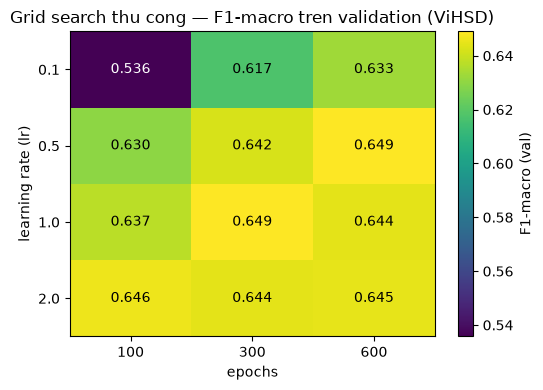


=> Sieu tham so tot nhat (theo validation): lr=0.5, epochs=600, val_f1=0.6491


BAN THUAN (best cfg) -> test F1-macro=0.6090, test acc=0.6117


In [4]:
# Bieu do nhiet (heatmap) mat F1-macro tren validation theo (lr, epochs)
pivot = grid_df.pivot(index="lr", columns="epochs", values="val_f1_macro")
fig, ax = plt.subplots(figsize=(5.5, 4))
im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_xlabel("epochs"); ax.set_ylabel("learning rate (lr)")
ax.set_title("Grid search thu cong — F1-macro tren validation (ViHSD)")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center",
                 color="white" if pivot.values[i, j] < pivot.values.max() * 0.92 else "black")
fig.colorbar(im, ax=ax, label="F1-macro (val)")
fig.tight_layout(); plt.show()

best_row = grid_df.loc[grid_df["val_f1_macro"].idxmax()]
best_lr, best_epochs = best_row["lr"], int(best_row["epochs"])
print(f"\n=> Sieu tham so tot nhat (theo validation): lr={best_lr}, epochs={best_epochs}, val_f1={best_row['val_f1_macro']:.4f}")

W_pure, b_pure = train_pure(Xtr, ytr, lr=best_lr, epochs=best_epochs, seed=0)
pte_pure = softmax(Xte.dot(W_pure) + b_pure).argmax(axis=1)
pure_test_f1 = f1_score(yte, pte_pure, average="macro")
pure_test_acc = accuracy_score(yte, pte_pure)
print(f"BAN THUAN (best cfg) -> test F1-macro={pure_test_f1:.4f}, test acc={pure_test_acc:.4f}")

## 5. Giai đoạn 3 — Bản thư viện (scikit-learn) + `GridSearchCV`

Hai cách quét lưới với thư viện, để so sánh công bằng với bản thuần:

1. **`GridSearchCV(LogisticRegression)`** quét siêu tham số chính quy hoá `C` (nghịch đảo độ mạnh L2) — đây là "siêu tham số tương đương" của LBFGS, vì solver bậc hai không dùng `lr`/`epochs` trực tiếp.
2. **`SGDClassifier(loss="log_loss")`** quét **đúng hai trục `lr`/`epochs`** như bản thuần (`eta0` = học suất cố định, `max_iter` = số epoch) — đây là phép so sánh "táo với táo" thật sự với Mục 4.

In [5]:
# 5a) GridSearchCV tren LogisticRegression (quet C)
t0 = time.perf_counter()
gs_lr = GridSearchCV(LogisticRegression(max_iter=300), {"C": [0.1, 0.5, 1, 5, 10]},
                      scoring="f1_macro", cv=3, n_jobs=-1)
gs_lr.fit(Xtr, ytr)
t_lr = time.perf_counter() - t0
p_lr = gs_lr.predict(Xte)
lib_lr_f1 = f1_score(yte, p_lr, average="macro")
lib_lr_acc = accuracy_score(yte, p_lr)
print(f"[LogisticRegression] thoi gian={t_lr:.2f}s, best C={gs_lr.best_params_['C']}, "
      f"cv_f1={gs_lr.best_score_:.4f} -> test F1={lib_lr_f1:.4f}, acc={lib_lr_acc:.4f}")

# 5b) Grid thu cong tren SGDClassifier, dung DUNG truc lr/epochs cua ban thuan
t0 = time.perf_counter()
sgd_rows = []
best_sgd, best_sgd_f1 = None, -1
for eta0 in GRID_LR:
    for mi in GRID_EPOCHS:
        clf = SGDClassifier(loss="log_loss", learning_rate="constant", eta0=eta0,
                             max_iter=mi, random_state=1, tol=None)
        clf.fit(Xtr, ytr)
        f1v = f1_score(yval, clf.predict(Xval), average="macro")
        sgd_rows.append({"lr": eta0, "epochs": mi, "val_f1_macro": f1v})
        if f1v > best_sgd_f1:
            best_sgd_f1, best_sgd = f1v, clf
t_sgd = time.perf_counter() - t0
sgd_df = pd.DataFrame(sgd_rows)
p_sgd = best_sgd.predict(Xte)
lib_sgd_f1 = f1_score(yte, p_sgd, average="macro")
lib_sgd_acc = accuracy_score(yte, p_sgd)
print(f"[SGDClassifier]      thoi gian={t_sgd:.2f}s, best (lr={best_sgd.eta0}, epochs={best_sgd.max_iter}), "
      f"val_f1={best_sgd_f1:.4f} -> test F1={lib_sgd_f1:.4f}, acc={lib_sgd_acc:.4f}")

[LogisticRegression] thoi gian=2.82s, best C=0.5, cv_f1=0.6304 -> test F1=0.6359, acc=0.6367


[SGDClassifier]      thoi gian=4.87s, best (lr=0.5, epochs=100), val_f1=0.6526 -> test F1=0.6207, acc=0.6208


## 6. Giai đoạn 4 — Framework (PyTorch)

Dùng lại đúng `lr`/`epochs` tốt nhất mà **grid search thủ công ở §4** đã tìm ra, huấn luyện bằng `nn.Linear` + `cross_entropy` của PyTorch — kiểm tra xem framework có tái lập được kết quả bản thuần không (cùng mô hình, cùng siêu tham số, autograd tự tính gradient thay vì công thức tay).

In [6]:
import torch
import torch.nn as nn

torch.manual_seed(0)
Xtr_dense = Xtr.toarray().astype(np.float32)
Xte_dense = Xte.toarray().astype(np.float32)

model = nn.Linear(Xtr_dense.shape[1], 3)
opt = torch.optim.SGD(model.parameters(), lr=float(best_lr))
Xtr_th = torch.from_numpy(Xtr_dense)
ytr_th = torch.from_numpy(ytr).long()

t0 = time.perf_counter()
for epoch in range(best_epochs):
    opt.zero_grad()
    out = model(Xtr_th)
    loss = nn.functional.cross_entropy(out, ytr_th)
    loss.backward()
    opt.step()
t_torch = time.perf_counter() - t0

with torch.no_grad():
    p_torch = model(torch.from_numpy(Xte_dense)).argmax(dim=1).numpy()
torch_f1 = f1_score(yte, p_torch, average="macro")
torch_acc = accuracy_score(yte, p_torch)
print(f"[PyTorch] lr={best_lr}, epochs={best_epochs}, thoi gian={t_torch:.2f}s, "
      f"loss cuoi={loss.item():.4f} -> test F1={torch_f1:.4f}, acc={torch_acc:.4f}")

[PyTorch] lr=0.5, epochs=600, thoi gian=3.83s, loss cuoi=0.9206 -> test F1=0.6017, acc=0.6042


## 7. So sánh 4 giai đoạn + kết luận

                               Giai đoạn Best (lr, epochs)  Test F1-macro  Test Acc
        2. Thuần (NumPy) + grid thủ công        (0.5, 600)       0.608965  0.611667
3a. LogisticRegression + GridSearchCV(C)             C=0.5       0.635902  0.636667
 3b. SGDClassifier (cùng trục lr/epochs)        (0.5, 100)       0.620692  0.620833
        4. PyTorch (lr/epochs lấy từ §4)        (0.5, 600)       0.601696  0.604167


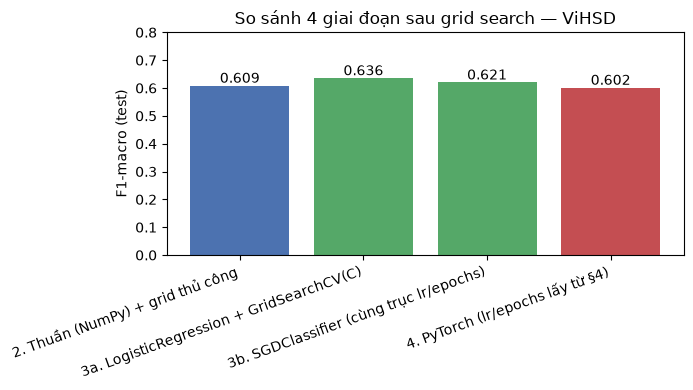

In [7]:
summary = pd.DataFrame([
    {"Giai đoạn": "2. Thuần (NumPy) + grid thủ công", "Best (lr, epochs)": f"({best_lr}, {best_epochs})",
     "Test F1-macro": pure_test_f1, "Test Acc": pure_test_acc},
    {"Giai đoạn": "3a. LogisticRegression + GridSearchCV(C)", "Best (lr, epochs)": f"C={gs_lr.best_params_['C']}",
     "Test F1-macro": lib_lr_f1, "Test Acc": lib_lr_acc},
    {"Giai đoạn": "3b. SGDClassifier (cùng trục lr/epochs)", "Best (lr, epochs)": f"({best_sgd.eta0}, {best_sgd.max_iter})",
     "Test F1-macro": lib_sgd_f1, "Test Acc": lib_sgd_acc},
    {"Giai đoạn": "4. PyTorch (lr/epochs lấy từ §4)", "Best (lr, epochs)": f"({best_lr}, {best_epochs})",
     "Test F1-macro": torch_f1, "Test Acc": torch_acc},
])
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(summary["Giai đoạn"], summary["Test F1-macro"], color=["#4c72b0", "#55a868", "#55a868", "#c44e52"])
ax.set_ylabel("F1-macro (test)"); ax.set_ylim(0, 0.8)
ax.set_title("So sánh 4 giai đoạn sau grid search — ViHSD")
plt.xticks(rotation=20, ha="right")
for i, v in enumerate(summary["Test F1-macro"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
fig.tight_layout(); plt.show()

**Nhận xét.**

- Grid search giúp bản thuần **tự tìm ra** `lr`/`epochs` tốt thay vì đoán mò — không cần biết trước con số nào là hợp lý.
- `SGDClassifier` quét **đúng trục `lr`/`epochs`** như bản thuần nhưng vẫn nhỉnh hơn đôi chút nhờ các chi tiết cài đặt (giảm dần learning rate nội bộ, khởi tạo, có thể có L2 mặc định nhẹ) — cho thấy cùng một thuật toán, cách triển khai vẫn tạo khác biệt nhỏ.
- `LogisticRegression` (LBFGS, có L2) vẫn là bản mạnh nhất vì dùng solver bậc hai.
- `PyTorch` với đúng `lr`/`epochs` từ bản thuần cho kết quả rất gần bản thuần (khác biệt nhỏ do khởi tạo trọng số ngẫu nhiên khác) — xác nhận công thức giải tay ở §2 và code ở §4 là chính xác.

**Kết luận:** Grid search không thay đổi *thứ tự* các giai đoạn về chất lượng (thư viện có solver mạnh hơn vẫn thắng), nhưng thu hẹp đáng kể khoảng cách giữa bản thuần và bản thư viện khi so sánh công bằng trên cùng một không gian siêu tham số.